<a href="https://colab.research.google.com/github/benasphy/Eduera_ML_Projects/blob/main/SVM_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- **Import Libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

- **Generate synthetic data**

In [2]:
np.random.seed(42)
n_samples = 100

#Circles - Class 0
angles_circle = 2 *np.pi *np.random.rand(n_samples)
r_circle = 0.5 + 0.1 * np.random.randn(n_samples)
X_circle = np.c_[r_circle * np.cos(angles_circle), r_circle * np.sin(angles_circle)]
y_circle = np.zeros(n_samples)

#Triangles - Class 1
X_triangle = np.random.rand(n_samples, 2)
X_triangle[:, 1] = X_triangle[:, 1] * (1 - X_triangle[:, 0])
y_triangle = np.ones(n_samples)

#combine the datasets
X = np.vstack([X_circle, X_triangle])
y = np.hstack([y_circle, y_triangle])

- **Train SVM**

In [3]:
clf = SVC(kernel="rbf", C=10, gamma=0.5)
clf.fit(X, y)

SVC(C=10, gamma=0.5)

- **Predictions & accuracy**

In [4]:
y_pred = clf.predict(X)
print("Training Accuracy:", accuracy_score(y, y_pred))

Training Accuracy: 0.805


- **Plot decision boundary**

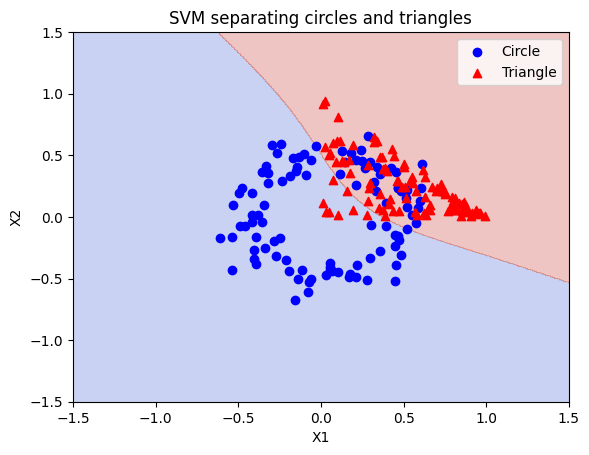

In [5]:
xx, yy = np.meshgrid(
    np.linspace(-1.5, 1.5, 500),
    np.linspace(-1.5, 1.5, 500)
)
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# Plot circles
plt.scatter(X_circle[:, 0], X_circle[:, 1], c="blue", marker="o", label="Circle")
# Plot triangles
plt.scatter(X_triangle[:, 0], X_triangle[:, 1], c="red", marker="^", label="Triangle")

plt.legend()
plt.title("SVM separating circles and triangles")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()